In [13]:
!pip install -U scikit-learn

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import MinMaxScaler
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.optimizers import Adam

In [15]:
# 1. Deteksi environment (Kaggle vs Lokal)
cwd = os.getcwd()

if "/kaggle" in cwd:
    # Base folder jika dijalankan di Kaggle
    BASE_DIR = os.path.join("/kaggle", "input", "datasets", "jerismeteo", "open-meteo-data-kebumen")
else:
    # Base folder jika dijalankan di laptop/komputer lokal
    BASE_DIR = cwd

# 2. Tentukan nama sub-folder dan file
FOLDER_DATA = "open_meteo_jerukagung"
NAMA_FILE = "cuaca_jerukagung.csv"
PATH_FILE = os.path.join(BASE_DIR, FOLDER_DATA, NAMA_FILE)

# Label Kelas (Sesuai Request)
CLASSES = {
    0: "☀️ Berawan / Cerah (0 mm)",
    1: "☁️ Hujan Ringan (0.1 - 5 mm)",
    2: "🌧️ Hujan Sedang (5 - 10 mm)",
    3: "⛈️ Hujan Lebat (10 - 20 mm)",
    4: "🚨 Sangat Lebat (> 20 mm)"
}

In [16]:
# ==============================================================================
# 2. LOAD DATA & BERSIHKAN WAKTU
# ==============================================================================
def load_data(filepath):
    print(f"📂 Membaca file: {filepath}")
    if not os.path.exists(filepath):
        print("❌ File tidak ditemukan.")
        return None
    
    # Baca CSV
    df = pd.read_csv(filepath, index_col='date', parse_dates=True)
    
    # Perbaikan Zona Waktu (Agar tidak geser)
    # 1. Baca sebagai UTC
    df.index = pd.to_datetime(df.index, utc=True)
    # 2. Geser ke WIB
    df.index = df.index.tz_convert('Asia/Jakarta')
    # 3. Hapus label zona waktu (biar jadi jam dinding polos)
    df.index = df.index.tz_localize(None)
    
    df = df.sort_index()
    print(f"✅ Data Siap! Rentang: {df.index.min()} s.d {df.index.max()}")
    return df

df = load_data(PATH_FILE)

# Ambil data 10 tahun terakhir agar relevan dan training tidak terlalu lama
# (Silakan ubah tahunnya jika mau lebih banyak data)
df_ai = df.loc['2017':].copy()

📂 Membaca file: /kaggle/input/datasets/jerismeteo/open-meteo-data-kebumen/open_meteo_jerukagung/cuaca_jerukagung.csv
✅ Data Siap! Rentang: 1975-01-01 00:00:00 s.d 2026-06-01 23:00:00


In [17]:
# ==============================================================================
# 3. FEATURE ENGINEERING (PEMBAGIAN KELAS)
# ==============================================================================
def categorize_rain(mm):
    """Mengelompokkan curah hujan per jam sesuai standar."""
    if mm < 0.1:   return 0  # Tidak Hujan
    elif mm < 5.0: return 1  # Ringan
    elif mm < 10.0: return 2 # Sedang
    elif mm < 20.0: return 3 # Lebat
    else: return 4           # Sangat Lebat

# Terapkan kategori ke kolom baru
df_ai['target_class'] = df_ai['rain_mm'].apply(categorize_rain)

print("\n📊 Distribusi Data per Kelas:")
print(df_ai['target_class'].value_counts().sort_index())


📊 Distribusi Data per Kelas:
target_class
0    48551
1    33209
2      523
3      122
4      131
Name: count, dtype: int64


In [18]:
# ==============================================================================
# 4. PRE-PROCESSING (SCALING & WINDOWING)
# ==============================================================================
# Fitur Input (X)
features = [
    'temperature_era5', 
    'humidity_era5', 
    'rain_mm', 
    'wind_speed_era5', 
    'pressure_era5', 
    'sealevel_pressure_era5']
# Target Output (y)
target = 'target_class'

# Scaling Input (Agar angka 0-1)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df_ai[features])
y_raw = df_ai[target].values

# Fungsi Sliding Window (Melihat masa lalu)
def create_windows(X, y, time_steps=24):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

print("\n✂️ Memotong data per 24 jam (Windowing)...")
TIME_STEPS = 24 
X_window, y_window = create_windows(X_scaled, y_raw, TIME_STEPS)

# Split Training (80%) dan Testing (20%)
split_idx = int(len(X_window) * 0.8)
X_train, y_train = X_window[:split_idx], y_window[:split_idx]
X_test, y_test = X_window[split_idx:], y_window[split_idx:]

print(f"Data Latih: {X_train.shape}")
print(f"Data Uji  : {X_test.shape}")


✂️ Memotong data per 24 jam (Windowing)...
Data Latih: (66009, 24, 6)
Data Uji  : (16503, 24, 6)


In [19]:
# --- HITUNG CLASS WEIGHT (PENTING!) ---
# Agar AI tidak meremehkan hujan lebat yang jarang terjadi
weights = class_weight.compute_class_weight(
    class_weight='balanced', 
    classes=np.unique(y_train), 
    y=y_train
)
class_weights_dict = dict(enumerate(weights))
print("⚖️ Bobot Penyeimbang Kelas:", class_weights_dict)

⚖️ Bobot Penyeimbang Kelas: {0: np.float64(0.327897272862749), 1: np.float64(0.5224711097039734), 2: np.float64(34.20155440414508), 3: np.float64(167.1113924050633), 4: np.float64(942.9857142857143)}


In [28]:
# ==============================================================================
# 5. MEMBANGUN MODEL LSTM
# ==============================================================================
model = Sequential()

# Layer 1: LSTM yang lebih ramping
model.add(LSTM(units=64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))

# Layer 2: LSTM terakhir (Kita buang LSTM ke-3 yang terlalu dalam)
model.add(LSTM(units=32, return_sequences=False))
model.add(Dropout(0.2))

# Layer 3: Dense (Hidden Layer)
# Cukup satu hidden layer untuk menjembatani logika
model.add(Dense(units=16, activation='relu'))

# Layer Output: 1 Neuron 
# PENTING: Gunakan 'linear', BUKAN 'relu'. Biarkan model menebak bebas.
model.add(Dense(units=1, activation='linear'))

# --- OUTPUT LAYER ---
model.add(Dense(5, activation='softmax'))

# Kompilasi Model
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

# Ganti MSE dengan Huber Loss. 
# Huber tidak terlalu panik saat melihat hujan ekstrem (outliers), 
# sehingga model lebih berani menebak fluktuasi grafik daripada membuat garis flat.
model.compile(optimizer=optimizer, 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 24, 64)         │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            17 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 5)              │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,147 (121.67 KB)

 Trainable params: 31,147 (121.67 KB)

 Non-trainable params: 0 (0.00 B)


Mulai Training
Epoch 1/50
929/929 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.3699 - loss: 1.5529 - val_accuracy: 0.0014 - val_loss: 1.6794
Epoch 2/50
929/929 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.3833 - loss: 1.5009 - val_accuracy: 0.4689 - val_loss: 1.3698
Epoch 3/50
929/929 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.4049 - loss: 1.4119 - val_accuracy: 0.5128 - val_loss: 1.3561
Epoch 4/50
929/929 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.4287 - loss: 1.2444 - val_accuracy: 0.5226 - val_loss: 1.1852
Epoch 5/50
929/929 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.5025 - loss: 1.2002 - val_accuracy: 0.5189 - val_loss: 1.1173
Epoch 6/50
929/929 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.5447 - loss: 1.1278 - val_accuracy: 0.5322 - val_loss: 1.0142
Epoch 7/50
929/929 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.5667 - loss: 1.1341 - val_accuracy: 0.5105 - val_loss: 1.1942
Epoch 8/50
929/929 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.5591 - loss: 1.1428 -

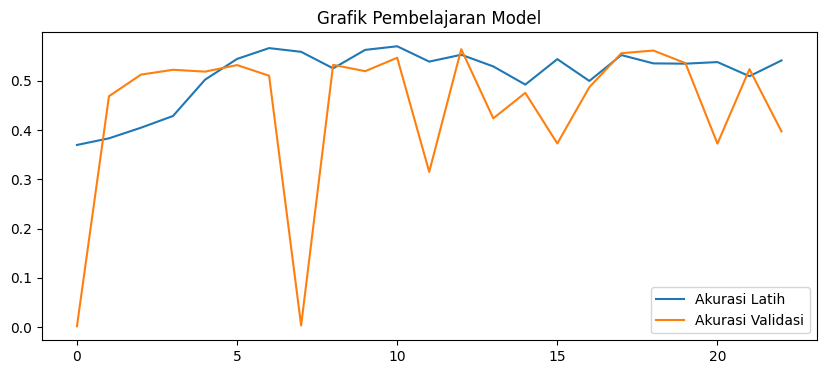

In [29]:
# ==============================================================================
# 6. TRAINING (MELATIH OTAK AI)
# ==============================================================================
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("\nMulai Training")
history = model.fit(
    X_train, y_train,
    epochs=50,           
    batch_size=64,
    validation_split=0.1,
    class_weight=class_weights_dict, # Wajib pakai ini
    callbacks=[early_stop],
    verbose=1
)

# Plot History Belajar
plt.figure(figsize=(10, 4))
plt.plot(history.history['accuracy'], label='Akurasi Latih')
plt.plot(history.history['val_accuracy'], label='Akurasi Validasi')
plt.title('Grafik Pembelajaran Model')
plt.legend()
plt.show()


📊 EVALUASI MODEL:
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
                              precision    recall  f1-score   support

   ☀️ Berawan / Cerah (0 mm)       0.59      0.77      0.67      8270
☁️ Hujan Ringan (0.1 - 5 mm)       0.61      0.34      0.44      7936
 🌧️ Hujan Sedang (5 - 10 mm)       0.06      0.54      0.11       137
 ⛈️ Hujan Lebat (10 - 20 mm)       0.18      0.28      0.22        43
    🚨 Sangat Lebat (> 20 mm)       0.16      0.03      0.06       117

                    accuracy                           0.56     16503
                   macro avg       0.32      0.39      0.30     16503
                weighted avg       0.59      0.56      0.55     16503



/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 127783 (\N{CLOUD WITH RAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9928 (\N{THUNDER CLOUD AND RAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127783 (\N{CLOUD WITH RAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9928 (\N{THUNDER CLOUD AND RAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128680

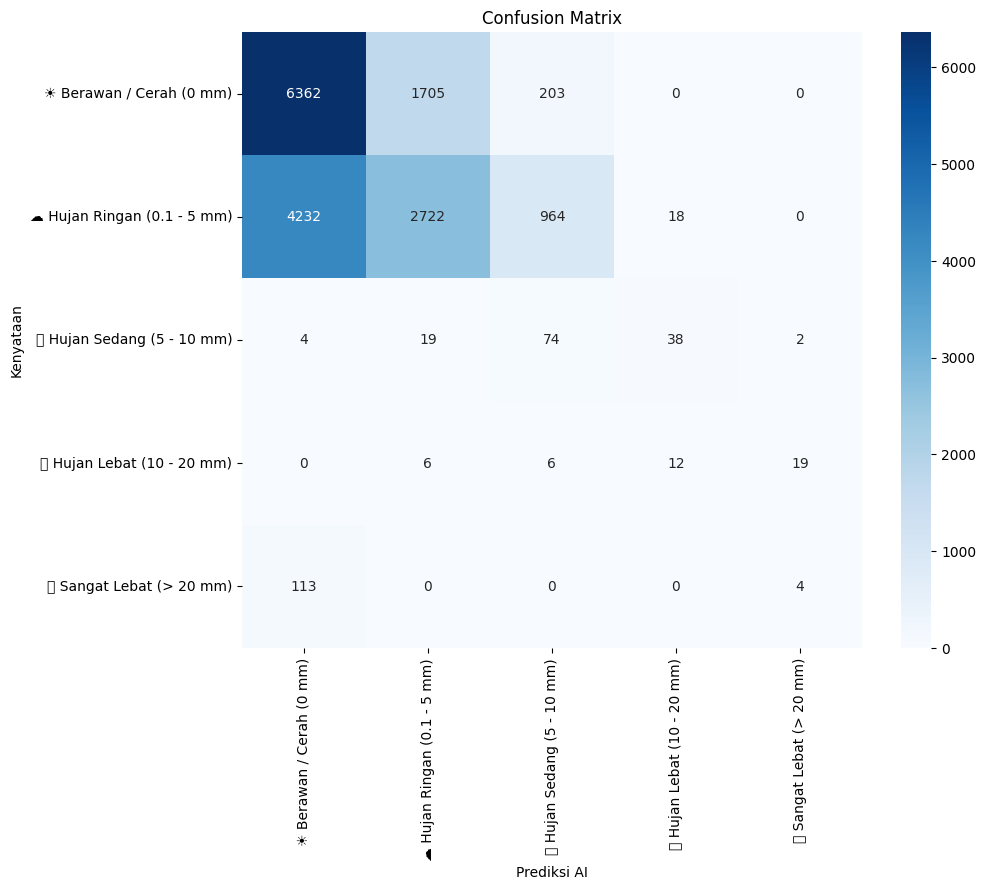

In [30]:
# ==============================================================================
# 7. EVALUASI HASIL
# ==============================================================================
print("\n📊 EVALUASI MODEL:")
y_pred_prob = model.predict(X_test)
y_pred_class = np.argmax(y_pred_prob, axis=1)

target_names = [CLASSES[i] for i in range(5)]
print(classification_report(y_test, y_pred_class, target_names=target_names))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_class)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Prediksi AI')
plt.ylabel('Kenyataan')
plt.title('Confusion Matrix')
plt.show()

In [31]:
# ==============================================================================
# 8. DEMO PREDIKSI (KARTU CUACA)
# ==============================================================================
def tampilkan_kartu_prediksi(input_24jam):
    """Menampilkan prediksi dengan gaya persentase."""
    input_reshaped = input_24jam.reshape(1, TIME_STEPS, len(features))
    probs = model.predict(input_reshaped, verbose=0)[0]
    
    pred_idx = np.argmax(probs)
    confidence = probs[pred_idx] * 100
    
    print("\n" + "="*50)
    print(f"🔮 PREDIKSI CUACA (1 Jam Kedepan)")
    print("="*50)
    
    print(f"Hasil Utama    : {CLASSES[pred_idx]}")
    print(f"Tingkat Yakin  : {confidence:.1f}%")
    print("-" * 50)
    
    print("Probabilitas:")
    for idx, label in CLASSES.items():
        score = probs[idx] * 100
        bar = "█" * int(score / 4)
        marker = "👈" if idx == pred_idx else ""
        print(f"{label:<30} : {score:>5.1f}% | {bar} {marker}")
    print("="*50)

# Coba cari data yang aslinya Hujan Lebat (Kelas 3 atau 4) untuk dites
print("\n🧪 DEMO HASIL PADA DATA BADAI:")
badai_indices = np.where(y_test >= 3)[0] # Cari kelas 3 atau 4

if len(badai_indices) > 0:
    # Ambil satu contoh
    sample_idx = badai_indices[0]
    tampilkan_kartu_prediksi(X_test[sample_idx])
else:
    print("Tidak ada data badai di set pengujian untuk didemokan.")


🧪 DEMO HASIL PADA DATA BADAI:

🔮 PREDIKSI CUACA (1 Jam Kedepan)
Hasil Utama    : 🌧️ Hujan Sedang (5 - 10 mm)
Tingkat Yakin  : 47.0%
--------------------------------------------------
Probabilitas:
☀️ Berawan / Cerah (0 mm)      :   8.9% | ██ 
☁️ Hujan Ringan (0.1 - 5 mm)   :  17.3% | ████ 
🌧️ Hujan Sedang (5 - 10 mm)    :  47.0% | ███████████ 👈
⛈️ Hujan Lebat (10 - 20 mm)    :  21.9% | █████ 
🚨 Sangat Lebat (> 20 mm)       :   4.8% | █ 
